In [1]:
import pandas as pd


In [3]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

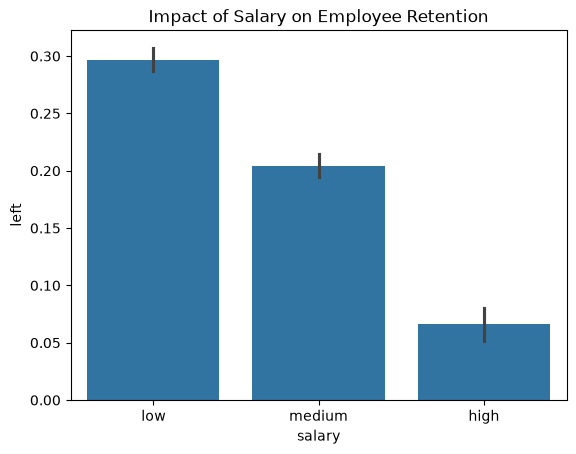

In [13]:
sns.barplot(x='salary', y='left', data=df)
plt.title("Impact of Salary on Employee Retention")
plt.show()


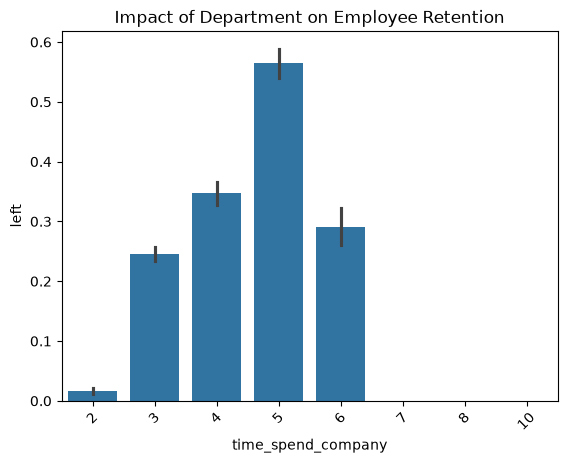

In [18]:
sns.barplot(x='time_spend_company', y='left', data=df)
plt.xticks(rotation=45)
plt.title("Impact of Department on Employee Retention")
plt.show()


In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df[['satisfaction_level','average_montly_hours',
        'promotion_last_5years',
        'salary']]
y = df['left']

ct = ColumnTransformer([
    ('categorical', OneHotEncoder(), ['promotion_last_5years','salary'])
], remainder='passthrough')

X_encoded = ct.fit_transform(X)
X_encoded,
X.head(),
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_encoded, y)


y_pred = model.predict(X_encoded)
print("Accuracy:", accuracy_score(y, y_pred))


Accuracy: 0.775718381225415
